In [1]:
import numpy as np #linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import plotly.graph_objs as go #visualization
import matplotlib.colors #visualization
import warnings
warnings.filterwarnings("ignore") #doesnt display warnings
import matplotlib.pyplot as plt #visualization
import seaborn as sns #visualization
import plotly as py #visualization
from datetime import datetime #for formatting
import datetime as dt

# Data Loading

The above code is to make the necessary imports of the packages used in the EDA and Plotting

In [2]:
amazon_csv = pd.read_csv('Amazon_prime_titles.csv')
amazon_csv.shape

(9667, 13)

Above code helps to read the data from CSV and for manipulating them easily

# Exploratory Data Analysis

### Lets analyse our data set by viewing a few of them

In [3]:
np.random.seed(0) #seed for reproducibility
amazon_csv.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,age_group,duration,listed_in,description,rating
3090,s3092,TV Show,Betsy's Kindergarten Adventures,NaN,"Nancy Cartwright, Tom Kenny, Daveigh Chase, Vi...",United Kingdom,NaN,2009,ALL,1 Season,"Animation, Kids","Told from the perspective of 5-year old Betsy,...",5.4
5221,s5223,Movie,Sandeep Aur Pinky Faraar,Dibakar Banerjee,"Parineeti Chopra, Arjun Kapoor, Neena Gupta, R...",India,NaN,2021,13+,123 min,"Drama, Romance, Suspense","Sandeep, a bank executive & Pinky, a suspended...",4.6
4277,s4279,Movie,Manchild: The Schea Cotton Story,Eric 'Ptah' Herbert,"Schea Cotton, Gaynell Cotton, James Cotton Sr....",India,NaN,2020,16+,79 min,"Documentary, Sports",Manchild is a documentary film that chronicles...,8.9
2664,s2666,TV Show,Dickensian,NaN,"Stephen Rea, Tuppence Middleton, Anton Lesser,...",United Kingdom,NaN,2016,TV-PG,1 Season,Drama,Set within the fictional realms of Charles Dic...,5.7
7906,s7908,TV Show,Super Wings,NaN,"Chasden Gilson-Walker, Cassandra Lee Morris, B...",India,29-Aug-21,2019,TV-Y,4 Seasons,"Animation, Kids",Super Wings is an action-packed upper-preschoo...,8.0


amazon_csv.sample() Randomly display the data set to give an idea about what we are dealing with

### Yes, it looks like there's some missing values.
### Lets do some Initial data exploration and data cleaning


In [4]:
# Operator to find null/ missing values
print('Percentage of null values in the given data set:')
for col in amazon_csv.columns:
  null_count = amazon_csv[col].isna().sum()/len(amazon_csv)*100
  if null_count > 0:
    print(f'{col}  : {round(null_count,2)}%')

Percentage of null values in the given data set:
director  : 21.54%
cast  : 12.75%
country  : 10.3%
date_added  : 98.4%
age_group  : 3.49%
rating  : 2.93%


Loops through the columns and finds the percentage of null values

In [5]:


# Define valid values
valid_types = {"Movie", "TV Show"}

# Find invalid values
invalid_types = amazon_csv[~amazon_csv['type'].isin(valid_types)]

# Check if any invalid values exist
if invalid_types.empty:
    print("Valid values")
else:
    print("\nInvalid 'type' values:")
    print(invalid_types['type'].unique())

Valid values


Above code checks if the type coulmn has any invalid values other than "TV Show" and "Movies"

In [6]:

# Check if there are any invalid ratings (less than 0 or greater than 10)
if ((amazon_csv['rating'] < 0.0) | (amazon_csv['rating'] > 10.0)).any():
    print("Invalid")
else:
    print("Valid range")

Valid range


Above code checks if the rating coulmn has any invalid values.



### Using Sea born lets visualize the data set. Since its I will use Amazon Prime color palette.

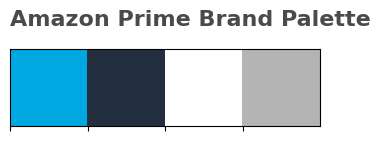

In [7]:

# Amazon Prime Video brand colors
sns.palplot(['#00A8E1', '#232F3E', '#FFFFFF', '#B4B4B4'])

plt.title("Amazon Prime Brand Palette", loc='left',  fontweight="bold",  fontsize=16, color='#4a4a4a', y=1.2)
plt.show()

## Summary statistics

In [8]:
# summary statistics
print("\nSummary Statistics:\n", amazon_csv.describe())


Summary Statistics:
        release_year       rating
count   9667.000000  9384.000000
mean    2008.340954     6.172847
std       18.923256     2.028165
min     1920.000000     1.000000
25%     2007.000000     4.800000
50%     2016.000000     6.300000
75%     2019.000000     7.600000
max     2021.000000     9.800000


The above code gives us the summary statistics of the data set.  IQR1, IQR2, Mean, Standard Deviation, Minimum value & Maximum values are shown.

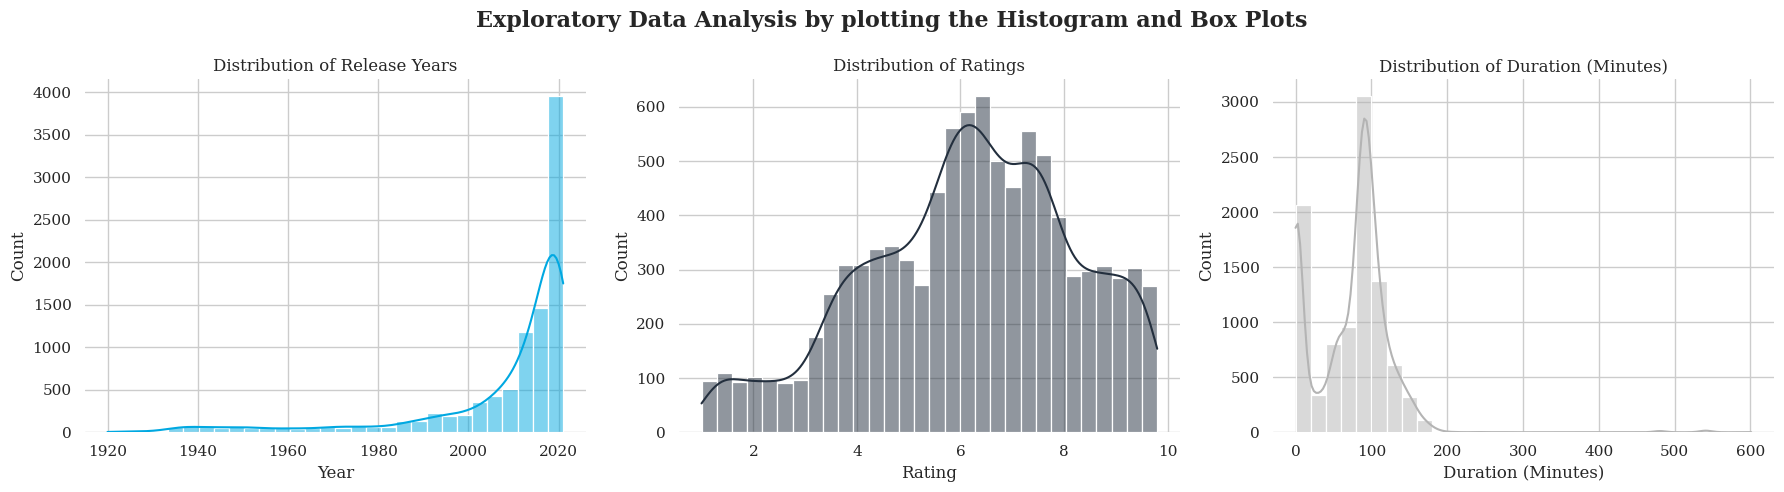

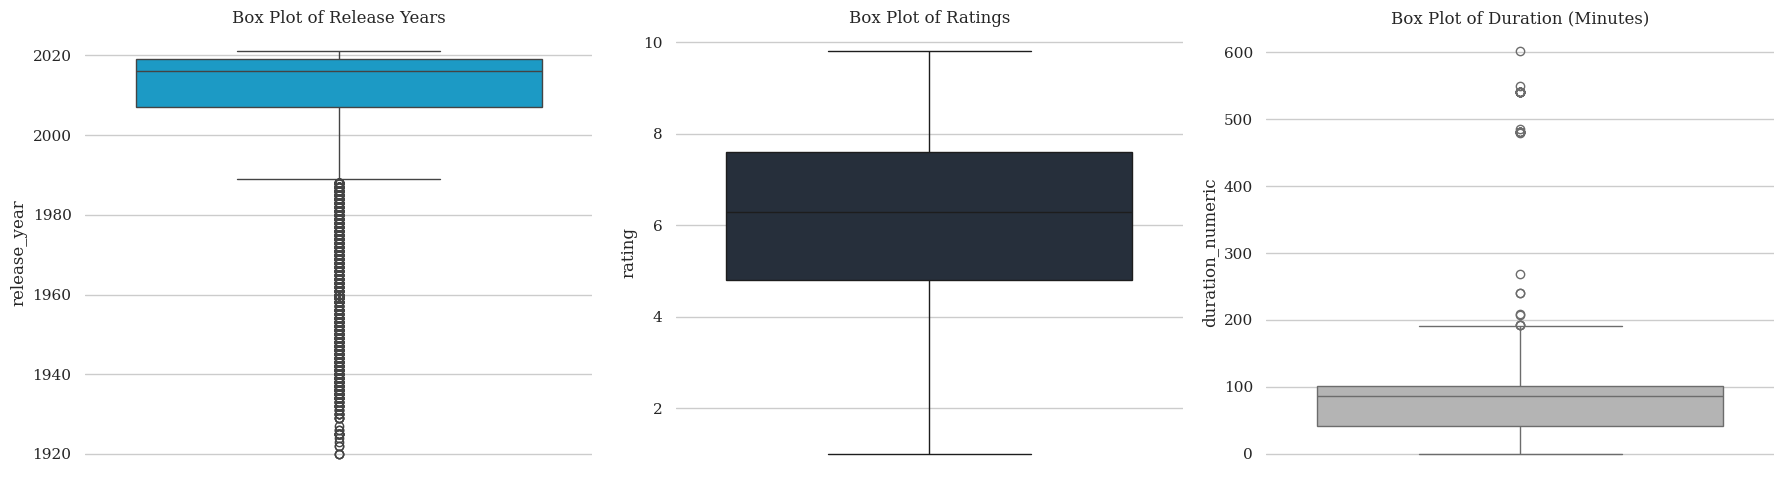

In [9]:




# new column 'duration_numeric'
amazon_csv['duration_numeric'] = amazon_csv['duration'].str.extract(r'(\d+)').astype(float)



#seaborn style and color palette
sns.set(style="whitegrid", rc={"font.family": "serif"})
palette = ['#00A8E1', '#232F3E', '#FFFFFF', '#B4B4B4']

#subplots for histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis by plotting the Histogram and Box Plots", fontsize=16, fontweight='bold', family='serif')

#to remove the border for aesthetics
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

# Histogram for Release Year
sns.histplot(amazon_csv['release_year'], bins=30, kde=True, ax=axes[0], color=palette[0])
axes[0].set_title("Distribution of Release Years")
axes[0].set_xlabel("Year")

# Histogram for Rating
sns.histplot(amazon_csv['rating'].dropna(), bins=30, kde=True, ax=axes[1], color=palette[1])
axes[1].set_title("Distribution of Ratings")
axes[1].set_xlabel("Rating")

# Histogram for Duration
sns.histplot(amazon_csv['duration_numeric'].dropna(), bins=30, kde=True, ax=axes[2], color=palette[3])
axes[2].set_title("Distribution of Duration (Minutes)")
axes[2].set_xlabel("Duration (Minutes)")

plt.tight_layout()
plt.show()

#  subplots for box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#to remove the border for aesthetics
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

# Box plot for Release Year
sns.boxplot(y=amazon_csv['release_year'], ax=axes[0], color=palette[0])
axes[0].set_title("Box Plot of Release Years")

# Box plot for Rating
sns.boxplot(y=amazon_csv['rating'], ax=axes[1], color=palette[1])
axes[1].set_title("Box Plot of Ratings")

# Box plot for Duration
sns.boxplot(y=amazon_csv['duration_numeric'], ax=axes[2], color=palette[3])
axes[2].set_title("Box Plot of Duration (Minutes)")
# display the plots
plt.tight_layout()
plt.show()


### **Histogram**: Displays the frequency distribution of content duration. Rating values has a bell shaped spread of data with values from 0 to 10, with a peak 7.0. Release year is skewed towards year towards 2005 and beyond. Shows that spread is more towards newer contents.
### **Boxplots**: Show the distribution of ratings and release years, highlighting outliers. The duration box plot shows a time duration of 600 minutes, which could be outlier or a lengthy movie.


 ### It's tracked that values are missing in 5 columns Director, Cast, Country , Date_added and  rating.


*  #### **Date added** columns has the **highest** missing counts
*  #### Missing values in **Ratings** are the **lowest**
*  #### Fair share of missing values in director, followed by cast, country and age_group column.


# Data Cleaning

## Let's deal with the missing Data

#### For the given dataset, with N = 7786, my approach for data cleaning will be:

 I will replace NULL values in the **'country'** column with the **MODE** value.  
 **Why:** Since the **'country'** column is categorical, replacing missing values with the most common country (the **mode**) seems like a good choice. Because I’m keeping the most frequent value, which makes sense for the analysis.

I will drop the row in the **'Cast'** column if it has NULL values.  
 **Why:** The **'Cast'** column is crucial for understanding the movie’s popularity. It’s better to drop that row so it doesn't mess up the analysis.

 I will drop the whole **'Date Added'** column since it might not provide any significant insight, especially since there are so many NULL values.  
 **Why:** **'Date Added'** has too many NULL values, and it’s probably not useful for the analysis.

 I will keep the **'Director'** as it is.  
 **Why:** The **'Director'** column seems important, and there doesn't seem to be much missing data here. So, it’s best to leave it untouched because it might provide important information for understanding the movie.


In [10]:
#Drop the column date_added
amazon_csv.drop(columns=['date_added'], inplace=True)

# Replace missing values in 'country' with its mode (most frequent value)
amazon_csv['country'].fillna(amazon_csv['country'].mode()[0], inplace=True)

# Replace missing values in 'director' and 'cast' with "Not available"
amazon_csv[['director', 'cast']] = amazon_csv[['director', 'cast']].fillna("Not available")

# Drop rows where 'age group' or 'rating' are missing
amazon_csv.dropna(subset=['age_group', 'rating'], inplace=True)

# Reset index after dropping rows
amazon_csv.reset_index(drop=True, inplace=True)

Above code
* drops the whole column "date_added",
* Drop rows where 'age group' or 'rating' are missing
* Replace missing values in 'country' with its mode
* Replace missing values in 'director' and 'cast' with "Not available"
* Reset index after dropping rows

# Data Visualization

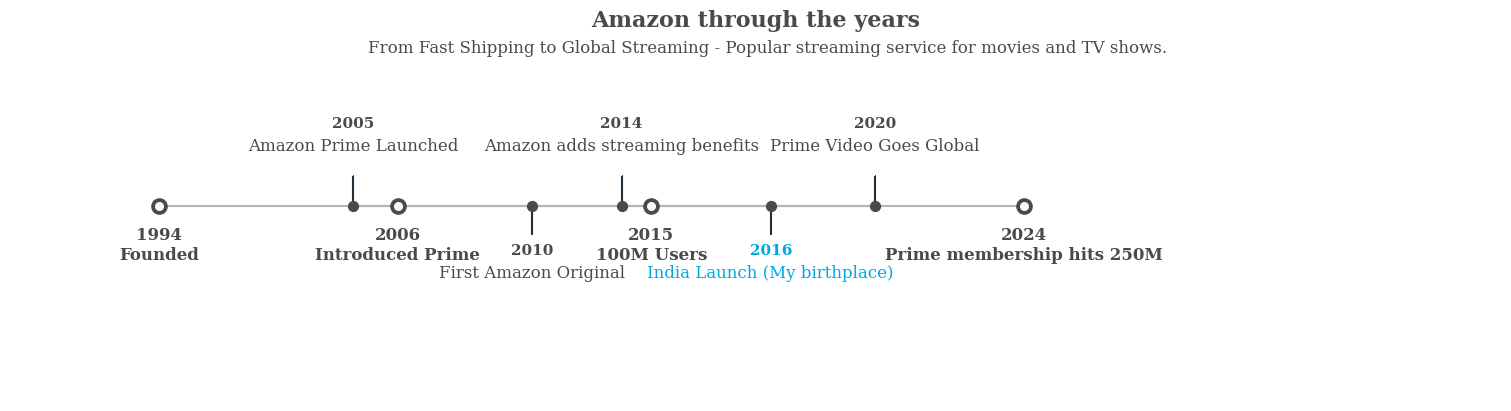

In [11]:
# Timeline plotting code inspired from Subin An's notebook

# Set figure & Axes
fig, ax = plt.subplots(figsize=(15, 4), constrained_layout=True)
ax.set_ylim(-2, 1.75)
ax.set_xlim(0, 10)


# Timeline : line
ax.axhline(0, xmin=0.1, xmax=0.68, c='#B4B4B4', zorder=1)
# these values go on the numbers below
tl_dates = [
    "1994\nFounded",
    "2006\nIntroduced Prime",
    "2015\n100M Users",
    "2024\nPrime membership hits 250M"
]

tl_x = [1, 2.6, 4.3,6.8]
## these go on the numbers
tl_sub_x = [2.3,3.5,4.1,5.1,5.8]

tl_sub_times = [
    "2005","2010","2014","2016","2020"
]
# these values go on Stemplot : vertical line
tl_text = [
    "Amazon Prime Launched","First Amazon Original","Amazon adds streaming benefits", "India Launch (My birthplace)", "Prime Video Goes Global"]

# Timeline : Date Points
ax.scatter(tl_x, np.zeros(len(tl_x)), s=120, c='#4a4a4a', zorder=2)
ax.scatter(tl_x, np.zeros(len(tl_x)), s=30, c='#fafafa', zorder=3)
# Timeline : Time Points
ax.scatter(tl_sub_x, np.zeros(len(tl_sub_x)), s=50, c='#4a4a4a',zorder=4)

# Date Text
for x, date in zip(tl_x, tl_dates):
    ax.text(x, -0.55, date, ha='center',
             fontweight='bold',
            color='#4a4a4a',fontfamily='serif',fontsize=12)

# Stemplot : vertical line
levels = np.zeros(len(tl_sub_x))
levels[::2] = 0.3
levels[1::2] = -0.3

markerline, stemline, baseline = ax.stem(tl_sub_x, levels)
plt.setp(baseline, zorder=0)
plt.setp(markerline, marker=',', color='#4a4a4a')
plt.setp(stemline, color='#232F3E')


# Remove the Spine around the plot
for spine in ["left", "top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

# Ticks
ax.set_xticks([])
ax.set_yticks([])

# Title
ax.set_title("Amazon through the years", fontweight="bold",  fontsize=16,fontfamily='serif', color='#4a4a4a')
ax.text(2.4,1.57,"From Fast Shipping to Global Streaming - Popular streaming service for movies and TV shows.",  fontsize=12, fontfamily='serif',color='#4a4a4a')

# Text
for idx, x, time, txt in zip(range(1, len(tl_sub_x)+1), tl_sub_x, tl_sub_times, tl_text):
    ax.text(x, 1.3*(idx%2)-0.5, time, ha='center',
             fontweight='bold',
            color='#4a4a4a' if idx!=len(tl_sub_x)-1 else '#00A8E1', fontfamily='serif',fontsize=11)

    ax.text(x, 1.3*(idx%2)-0.6, txt, va='top', ha='center',fontfamily='serif',
        color='#4a4a4a' if idx!=len(tl_sub_x)-1 else '#00A8E1')
plt.show()

In [12]:
amazon_csv['count'] = 1
# Extract the first country from the 'country' column
amazon_csv['first_country'] = amazon_csv['country'].apply(lambda x: x.split(",")[0])

# # Shorten country names for better readability
amazon_csv['first_country'].replace({'United States': 'USA',
                                     'United Kingdom': 'UK',
                                     'South Korea': 'S. Korea'}, inplace=True)


# Group by country and get the total count, then sort in descending order
countriess = amazon_csv.groupby('first_country')['count'].sum().sort_values(ascending=False)

Helper code for better display of country names , also since a few movies have more than one Country I am seggeregating. Also Group  country and get the total count and sort in descending order.

In [13]:
# Load the ISO code CSV data
iso_df = pd.read_csv('country_iso_codes.csv')


# Merge the country counts with the ISO codes
merged_df = pd.merge(countriess, iso_df, left_index=True, right_on='Country')


# Define Amazon Prime themed color scale for specific ranges for better visibility
custom_colorscale = [
    (0.0, '#00A8E1'),  # Highest values (Prime Blue)
    (0.1, '#0073CF'),  # 700-800 range (Deep Blue)
    (0.2, '#005BB5'),  # 600-700 range (Darker Blue)
    (0.3, '#004494'),  # 500-600 range (Navy Blue)
    (0.4, '#002E73'),  # 400-500 range (Deep Navy)
    (0.5, '#001A52'),  # 300-400 range (Dark Indigo)
    (0.6, '#232F3E'),  # 100-300 range (Amazon Dark Blue)
    (1.0, '#0F1111')   # 1-100 range (Almost Black)
]


# Create the choropleth map
fig = go.Figure(data=go.Choropleth(
    locations=merged_df['ISO Code'],  # Country ISO codes
    z=merged_df['count'],  # Data values
    text=merged_df['Country'],  # Hover text
    colorscale=custom_colorscale,
    marker_line_color='darkgray',
    marker_line_width=0.6,
    colorbar_title='Count',
))

# Update layout
fig.update_layout(
    title={
        'text': "TV Shows / Movies origin country available on Amazon Prime",
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(
            size=30,
            family='serif',
            weight='bold'
        ),
        'pad': dict(t=20)
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    )
)

# Show the figure
fig.show()

Load a new CSV for ISO Code of countries, as choropleth takes one of these as the input for plotting.
Merge this with the Amazon CSV to map it with the choropleth.

### We can clearly see that Majority of the content on Amazon Prime is produced in USA & then followed by India, UK, South Korea, France, Australia. This could be because of Hollywood and Bollywood which are major producers of Movies and TV Shows. Also, because of K Drama and K Pop, South Korea also holds a strong hold. But also could be a result of Population in the respective countries which increases the production of contents.

In [14]:
# Find the ratio of type
x=amazon_csv.groupby(['type'])['type'].count()
y=len(amazon_csv)
r=((x/y)).round(2)

mf_ratio = pd.DataFrame(r).T
print(mf_ratio)

type  Movie  TV Show
type    0.8      0.2


Above code finds the ratio of Movies to TV Shows for the next step in visualizing.

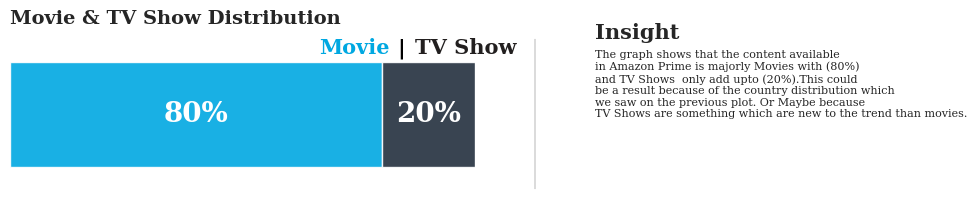

In [15]:


#calclated 'mf_ratio'
mf_ratio = pd.DataFrame({'Movie': [0.8], 'TV Show': [0.2]})

fig, ax = plt.subplots(figsize=(6, 1.5))

#  single horizontal stacked bar
ax.barh(0, mf_ratio['Movie'], color='#00A8E1', alpha=0.9)
ax.barh(0, mf_ratio['TV Show'], left=mf_ratio['Movie'], color='#232F3E', alpha=0.9)

# Remove axes details
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['top', 'left', 'right', 'bottom']].set_visible(False)

# Annotations for Movie & TV Show
ax.annotate("80%", xy=(mf_ratio['Movie'][0] / 2, 0), va='center', ha='center',  color='white', fontsize=20, fontweight='bold', fontfamily='serif')
ax.annotate("20%", xy=(mf_ratio['Movie'][0] + mf_ratio['TV Show'][0] / 2, 0), va='center', ha='center', fontsize=20, color='white', fontweight='bold', fontfamily='serif')
fig.text(1.1, 1, 'Insight', fontsize=15, fontweight='bold', fontfamily='serif')

fig.text(1.1, 0.40, '''
The graph shows that the content available
in Amazon Prime is majorly Movies with (80%)
and TV Shows  only add upto (20%).This could
be a result because of the country distribution which
we saw on the previous plot. Or Maybe because
TV Shows are something which are new to the trend than movies.
'''
         , fontsize=8, fontweight='light', fontfamily='serif')
# Creates a vertical line to seperate the insight
import matplotlib.lines as lines
l1 = lines.Line2D([1, 1], [0, 1], transform=fig.transFigure, figure=fig,color='black',lw=0.2)
fig.lines.extend([l1])

# Title
fig.text(0.125, 1.1, 'Movie & TV Show Distribution', fontsize=14, fontweight='bold', fontfamily='serif')

fig.text(0.64,0.9,"Movie", fontweight="bold", fontfamily='serif', fontsize=15, color='#00A8E1')
fig.text(0.77,0.9,"|", fontweight="bold", fontfamily='serif', fontsize=15, color='black')
fig.text(0.8,0.9,"TV Show", fontweight="bold", fontfamily='serif', fontsize=15, color='#221f1f')

plt.show()

To plot a single stacked bar from the caluclated ration. Also removes the box around the plot for better aesthetics.
text()  is used to plot the writing and give insights.
show() helps in displaying the graph.
Using matplotlib.lines Creates a vertical line to seperate the insight.
Annotations are plotted using annotate() function to show values on the stacks.



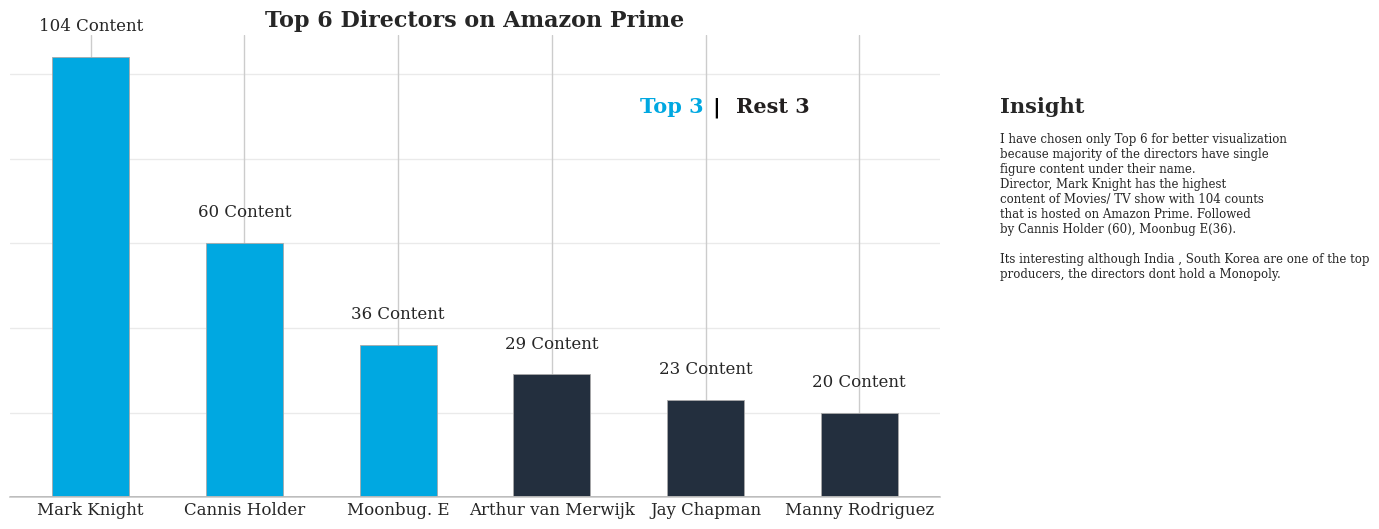

In [16]:


# Filter out 'Not Available' values before counting occurrences
filtered_directors = amazon_csv[amazon_csv['director'] != "Not available"]

# Count the number of titles per director
director_counts = filtered_directors['director'].value_counts()

# Select top 10 directors
top_directors = director_counts[:6]

# Define bar colors
colors = ['#232F3E'] * 10  # Default light color
colors[:3] = ['#00A8E1'] * 3  # Highlight top 3 directors

# Create figure and axis for the bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the bar chart
ax.bar(top_directors.index, top_directors.values, width=0.5, color=colors, edgecolor='darkgray', linewidth=0.6)

# Get the maximum value for dynamic annotation positioning
max_value = top_directors.max()

# Add value labels above the bars
for i, director in enumerate(top_directors.index):
    ax.annotate(f"{top_directors[director]} Content",
                xy=(i, top_directors[director] + max_value * 0.05),  # 5% above the bar
                ha='center', va='bottom', fontweight='light', fontfamily='serif')

# Remove top, left, and right borders
for side in ['top', 'left', 'right']:
    ax.spines[side].set_visible(False)

# Set x-axis labels
ax.set_xticks(range(len(top_directors.index)))  # Correct tick positioning
ax.set_xticklabels(top_directors.index, fontfamily='serif', rotation=0, ha='center')
ax.set_yticklabels('', fontfamily='serif', rotation=0, ha='center')


# Add horizontal grid lines for better readability
ax.grid(axis='y', linestyle='-', alpha=0.4)
ax.set_axisbelow(True)  # Place grid lines behind bars

# Add a thick bottom border
plt.axhline(y=0, color='black', linewidth=1.3, alpha=0.7)
fig.text(0.95, 0.75, 'Insight', fontsize=15, fontweight='bold', fontfamily='serif')

fig.text(0.95, 0.45, '''
I have chosen only Top 6 for better visualization
because majority of the directors have single
figure content under their name.
Director, Mark Knight has the highest
content of Movies/ TV show with 104 counts
that is hosted on Amazon Prime. Followed
by Cannis Holder (60), Moonbug E(36).

Its interesting although India , South Korea are one of the top
producers, the directors dont hold a Monopoly.
'''
         , fontsize=8.5, fontweight='light', fontfamily='serif')

# Remove tick marks
ax.tick_params(axis='both', which='major', labelsize=12, length=0)
fig.text(0.65,0.75,"Top 3", fontweight="bold", fontfamily='serif', fontsize=15, color='#00A8E1')
fig.text(0.71,0.75,"|", fontweight="bold", fontfamily='serif', fontsize=15, color='black')
fig.text(0.73,0.75,"Rest 3", fontweight="bold", fontfamily='serif', fontsize=15, color='#221f1f')
# Title styling
plt.title('Top 6 Directors on Amazon Prime', fontsize=16, fontweight='bold', fontfamily='serif')

# Display the plot
plt.show()

Plotting the bar graph. The code removes unavailable directors and counts  titles. Selects the top six, highlighting the top three.
 Bar chart is created with labels, grid lines.
 Using fig.text() Insights are added on the side. set_visible(False) Removes top, left, and right borders
 plt.show()  chart is displayed. plt.axhline adds a line below the graph.

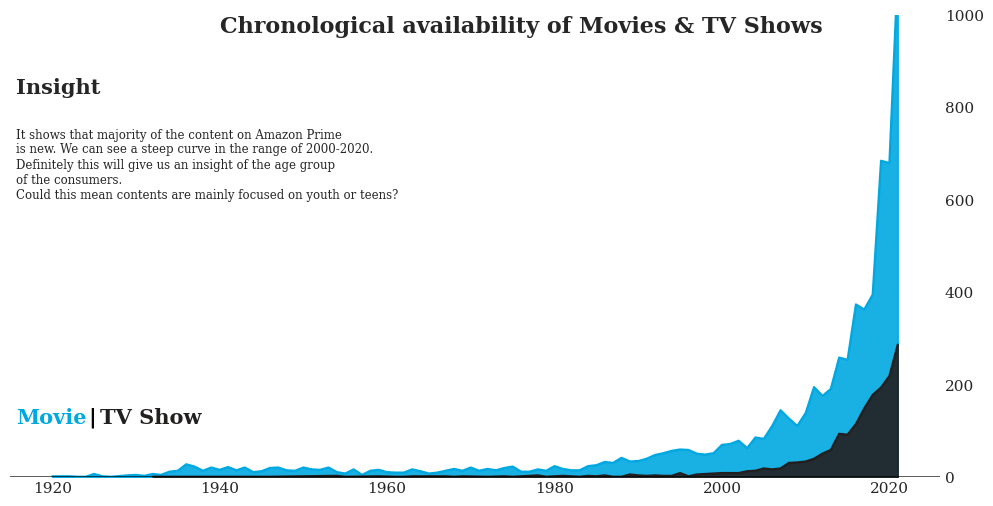

In [17]:
# To create a layout with length and width defined
fig, ax = plt.subplots(figsize=(12, 6))
color = ["#00A8E1", "#221f1f"]

# Annotation
for i, mtv in enumerate(amazon_csv['type'].value_counts().index):
    mtv_rel = amazon_csv[amazon_csv['type']==mtv]['release_year'].value_counts().sort_index()
    ax.plot(mtv_rel.index, mtv_rel, color=color[i], label=mtv)
    ax.fill_between(mtv_rel.index, 0, mtv_rel, color=color[i], alpha=0.9)

ax.yaxis.tick_right()
# Creates a horizontal line below in x axis
ax.axhline(y = 0, color = 'black', linewidth = 1.3, alpha = .7)
# Limits for the y axis ticks
ax.set_ylim(0, 1000)
#To remove the box around
for s in ['top', 'right','bottom','left']:
    ax.spines[s].set_visible(False)

ax.grid(False)
plt.xticks(fontfamily='serif')
plt.yticks(fontfamily='serif')
# Insights
fig.text(0.30, 0.85, 'Chronological availability of Movies & TV Shows', fontsize=16, fontweight='bold', fontfamily='serif')
fig.text(0.13, 0.75, 'Insight', fontsize=15, fontweight='bold', fontfamily='serif')
fig.text(0.13, 0.55,
'''It shows that majority of the content on Amazon Prime
is new. We can see a steep curve in the range of 2000-2020.
Definitely this will give us an insight of the age group
of the consumers.
Could this mean contents are mainly focused on youth or teens?
'''

, fontsize=8.5, fontweight='light', fontfamily='serif')
# Legends
fig.text(0.13,0.2,"Movie", fontweight="bold", fontfamily='serif', fontsize=15, color='#00A8E1')
fig.text(0.19,0.2,"|", fontweight="bold", fontfamily='serif', fontsize=15, color='black')
fig.text(0.2,0.2,"TV Show", fontweight="bold", fontfamily='serif', fontsize=15, color='#221f1f')
# removes the ticks
ax.tick_params(axis=u'both', which=u'both',length=0)
# Display the grapgh
plt.show()

Plotting the area graph using fill_between() . The code removes unavailable directors and counts  titles. Selects the top six, highlighting the top three.
 Bar chart is created with labels, grid lines.
 Using fig.text() Insights are added on the side. set_visible(False) Removes top, left, and right borders
 plt.show()  chart is displayed. plt.axhline adds a line below the graph Creates a horizontal line below in x axis. ax.set_ylim() Limits for the y axis ticks. ax.tick_params()  removes the ticks.

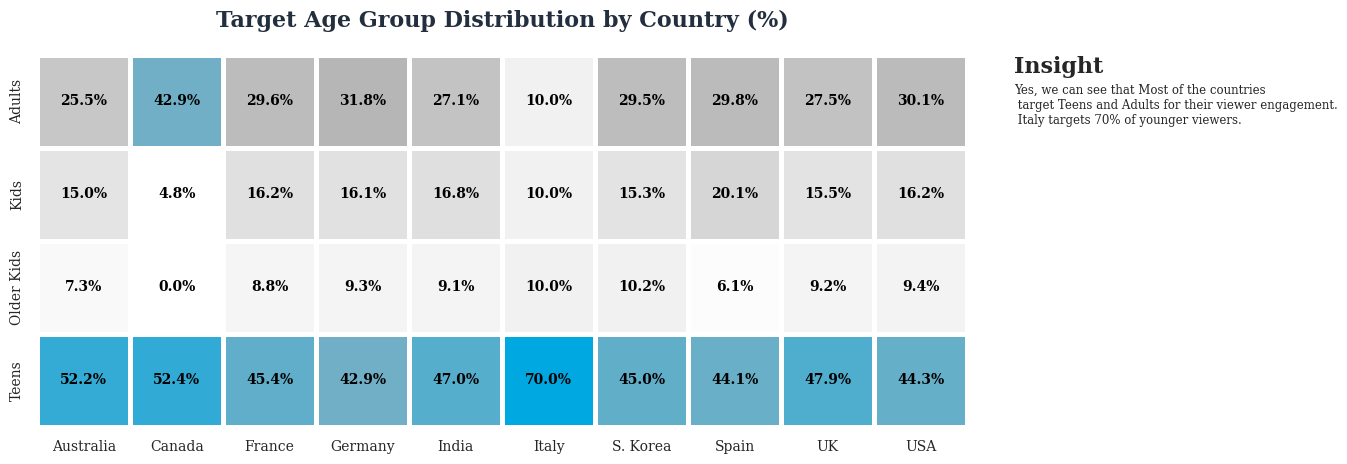

In [18]:



# Get the unique countries
unique_countries = set()
# Get the first country if multiple are listed
for entry in amazon_csv['country'].dropna():
    first_country = entry.split(', ')[0]
    unique_countries.add(first_country)

# Filter the dataset
amazon_csv['first_country'] = amazon_csv['country'].apply(lambda x: x.split(', ')[0] if isinstance(x, str) else x)

# Get the top 10 countries
top_countries = amazon_csv['first_country'].value_counts().head(10).index
# Creating a dictionary for clubbing
ratings_ages = {
    'TV-Y': 'Kids', 'TV-G': 'Kids', 'G': 'Kids', 'ALL': 'Kids', 'ALL_AGES': 'Kids',
    'TV-Y7': 'Older Kids', '7+': 'Older Kids', 'TV-PG': 'Older Kids', 'PG': 'Older Kids',
    'PG-13': 'Teens', 'TV-14': 'Teens', '13+': 'Teens', '16+': 'Teens', '16': 'Teens', 'AGES_16_': 'Teens',
    '18+': 'Adults', 'R': 'Adults', 'TV-MA': 'Adults', 'NC-17': 'Adults', 'NR': 'Adults', 'TV-NR': 'Adults',
    'UNRATED': 'Adults', 'AGES_18_': 'Adults', 'NOT_RATE': 'Adults'
}

# Create 'target_age_group' column *before* filtering
amazon_csv['target_age_group'] = amazon_csv['age_group'].map(ratings_ages)

# Filter data for only the top 10 countries
filtered_data = amazon_csv[amazon_csv['first_country'].isin(top_countries)]
filtered_data['first_country'].replace({'United States': 'USA',
                                     'United Kingdom': 'UK',
                                     'South Korea': 'S. Korea'}, inplace=True)
# Create a pivot table with counts of each age group per country
heatmap_data = filtered_data.pivot_table(index='target_age_group', columns='first_country', aggfunc='size', fill_value=0)

# Convert counts to percentages
heatmap_data_percentage = heatmap_data.div(heatmap_data.sum(axis=0), axis=1) * 100

# custom colormap for Amazon
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#FFFFFF', '#B4B4B4', '#00A8E1'])

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data_percentage, cmap=cmap, annot=True, fmt='.1f', linewidths=2.5, square=True,
            cbar=False, vmax=60, vmin=5, annot_kws={"fontsize": 12, "fontfamily": 'serif', "fontweight": 'bold', "color": 'black'})

# Annotations
for t in plt.gca().texts:
    t.set_text(t.get_text() + "%")
    t.set_fontsize(10)

# Title and labels
plt.title("Target Age Group Distribution by Country (%)", fontsize=16, fontweight='bold', fontfamily='serif', pad=20, color='#232F3E')
plt.xlabel("", fontsize=10, labelpad=10, fontfamily='serif', color='#232F3E')
plt.ylabel("", fontsize=10, labelpad=10, fontfamily='serif', color='#232F3E')

plt.xticks(fontsize=10, fontfamily='serif')
plt.yticks(fontsize=10, fontfamily='serif')

# Add  labels
plt.text(10.5, 0.2, "Insight", fontweight="bold", fontfamily='serif', fontsize=16)
plt.text(10.5, 0.9, '''Yes, we can see that Most of the countries
 target Teens and Adults for their viewer engagement.
 Italy targets 70% of younger viewers.
  ''', fontfamily='serif', fontsize=8.5)

# Show plot
plt.show()


Above code extracts the first country using .split(', ')[0] and identifies the top 10 countries using.value_counts().head(10).index.    maps age ratings to categories like 'Kids', 'Older Kids', 'Teens', and 'Adults' using ratings_ages. A pivot table is created using .pivot_table() to count occurrences of each age group per country. Generates a heatmap using sns.heatmap().

### Could the number of seasons of a TV Show has any relation with the rating? Usually TV Shows tend to increase their seasons if its a success or has a good engagegement.

In [19]:
amazon_csv['num_seasons'] = amazon_csv['duration'].str.extract(r'(\d+) Season[s]?')

From duration checks if the value has 'season' in it to confirm its TV Shows.

In [20]:

# Check correlation
correlation = amazon_csv['num_seasons'].corr(amazon_csv['rating'])
print(f"Correlation Coefficient: {correlation}")

Correlation Coefficient: 0.6789478121873362


### Correlation Coefficient is found between Number of Seasons in a TV Show and Rating value of it. To check for statistical signicance.

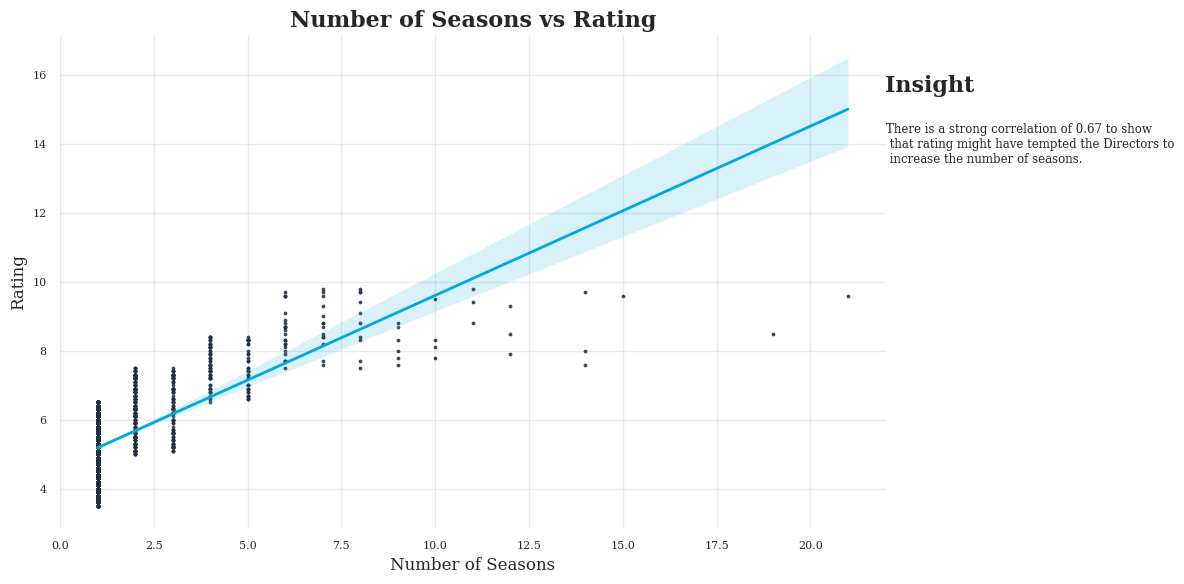

In [21]:

# Make it numeric to extract the number of seasons
amazon_csv['num_seasons'] = pd.to_numeric(amazon_csv['num_seasons'], errors='coerce')

# Create the regplot / Scatter plot
plt.figure(figsize=(12, 6))
sns.regplot(x=amazon_csv['num_seasons'], y=amazon_csv['rating'], scatter_kws={"s": 3, "color": "#232F3E"}, line_kws={"color": "#00A8E1", "linewidth": 2})

# Set title and labels
plt.title("Number of Seasons vs Rating", fontsize=16, fontweight='bold', family='serif')
plt.xlabel("Number of Seasons", fontsize=12, fontweight='normal', family='serif')
plt.ylabel("Rating", fontsize=12, fontweight='normal', family='serif')

# Grid customization
plt.grid(True, axis='both', linestyle='-', alpha=0.4)

# Make the background color white for a cleaner look
plt.gca().set_facecolor('white')
plt.text(22, 15.5, 'Insight', fontsize=16, fontweight='bold', fontfamily='serif')
plt.text(22, 13,
'''There is a strong correlation of 0.67 to show
 that rating might have tempted the Directors to
 increase the number of seasons.
'''

, fontsize=8.5, fontweight='light', fontfamily='serif')
# Customize the ticks
plt.xticks(fontsize=8, family='serif')
plt.yticks(fontsize=8, family='serif')

# Remove the borders (spines)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Display the plot
plt.tight_layout()
plt.show()

### There is a strong correlation of 0.67 to show that rating might have tempted the Directors to increase the number of seasons. But correlation doesnt imply causation so we cant predict AND confirm the analysis.

Above code pd.to_numeric() converts the 'num_seasons' column to numeric, Creates a scatter plot with regression line to analyze the relationship between Number of seasons and ratings. spine.set_visible() plt.title()
plt.xlabel()
plt.ylabel are used to customize the grid and labels

# **Exploratory Data Analysis (EDA) of Amazon Prime Titles**
### Word count: 391 

This analysis explores Amazon Prime’s content library using data from 9,667 titles, including movies and TV shows. The dataset contains attributes like title, type, release year, rating, and genre. The objective is to clean the data, handle missing values, and uncover trends in content distribution.

### **Data Cleaning and Preprocessing**

Missing values were found in multiple columns:
- "date_added" (98.4%) – Dropped due to excessive missing data.
- "country" (10.3%) – Filled with mode value.
- "director" (21.54%) and "cast" (12.75%) – Replaced with "Unknown."
- "rating" (2.93%) – Filled with mode value.

Checks ensured "type" only had "Movie" and "TV Show" values, and all ratings were valid.

### **Content Distribution and Trends**

- **Movies vs TV Shows**: The dataset contains 7,814 movies (80%) and 1,854 TV shows (20%).
- **Release Year Trends**: Content production increased after 2000, with a sharp rise post-2015.
- **Newer Content Preference**: 50% of content is from 2016 or later.

### **Genre and Audience Analysis**

- **Popular Categories**: "Drama," "Comedy," and "Suspense" dominate the dataset.
- **Ratings Breakdown**: PG, R, and TV-MA are common ratings, showing a mix of family-friendly and mature content.
- **Country-wise Production**:
  - USA leads content production.
  - India, UK, South Korea, and France follow.
  - Hollywood, Bollywood, and K-Dramas contribute significantly.

### **Duration and Rating Analysis**

- **Movies**: Average duration is 90 minutes.
- **TV Shows**: Ratings correlate strongly (0.67) with the number of seasons, suggesting successful shows get extended seasons.
- **Highest Rated Content**: Median rating is 6.3, with a maximum of 9.8.

### **Key Findings and Business Insights**
- **Content Type**: Majorly populated with Movies than TV Shows
- **Content Age**: Significant rise in content chronology distrubtion after 2010, majorly being newer releases.
- **Regional Availability**: USA dominates, but India and South Korea also have strong presence maybe due to Hollywood, Bollywood and KDrama.
- **Directors**: Mark Knight (104 titles) leads, followed by Cannis Holder (60) and Moonbug E (36). Notably, no monopoly among Indian and Korean directors even with higher content origin.
- **Statistical Insights**: Correlation between rating and number of TV show seasons suggests audience engagement influences newer releases.

### **Conclusion**

Amazon Prime’s content is heavily movie-focused. The platform’s diverse genre majorly targets Adult viewers but mix both family and mature audiences. These insights can help optimize content curation and engagement strategies.

